In [1]:
# IMPORT THƯ VIỆN CẦN THIẾT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **1. orders**

In [ ]:
# ĐỌC FILE orders.csv
orders = pd.read_csv('orders.csv')

In [ ]:
# HIỂN THỊ 5 DÒNG ĐẦU TIÊN
orders.head()

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [ ]:
# THÔNG TIN CÁC CỘT
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   order_id        646945 non-null  int64 
 1   order_date      646945 non-null  object
 2   customer_id     646945 non-null  int64 
 3   zip             646945 non-null  int64 
 4   order_status    646945 non-null  object
 5   payment_method  646945 non-null  object
 6   device_type     646945 non-null  object
 7   order_source    646945 non-null  object
dtypes: int64(3), object(5)
memory usage: 39.5+ MB


In [ ]:
# CONVERT DATATYPE CỘT order_date sang dạng DATATIME
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        646945 non-null  int64         
 1   order_date      646945 non-null  datetime64[ns]
 2   customer_id     646945 non-null  int64         
 3   zip             646945 non-null  int64         
 4   order_status    646945 non-null  object        
 5   payment_method  646945 non-null  object        
 6   device_type     646945 non-null  object        
 7   order_source    646945 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 39.5+ MB


**DESCRIPTION:**  ĐƠN HÀNG

| Cột            | Kiểu | Mô tả                                                                 |
|----------------|------|----------------------------------------------------------------------|
| order_id       | int  | Khoá chính                                                           |
| order_date     | date | Ngày đặt hàng                                                        |
| customer_id    | int  | FK → customers.customer_id                                           |
| zip            | int  | Mã bưu chính giao hàng (FK → geography.zip)                         |
| order_status   | str  | Trạng thái xử lý của đơn hàng (category)                            |
| payment_method | str  | Phương thức thanh toán được sử dụng (category)                      |
| device_type    | str  | Thiết bị khách hàng dùng khi đặt hàng (category)                    |
| order_source   | str  | Kênh marketing dẫn đến đơn hàng (category)                          |

In [ ]:
# THỐNG KÊ MÔ TẢ CÁC CỘT
print("THỐNG KÊ MÔ TẢ CÁC CỘT")
display(orders.describe())

THỐNG KÊ MÔ TẢ CÁC CỘT


,order_id,order_date,customer_id,zip
count,646945.000000,646945,646945.000000,646945.000000
mean,417189.470332,2016-11-28 05:46:39.463323904,84906.203535,55410.740423
min,1.000000,2012-07-04 00:00:00,1.000000,1001.000000
25%,208728.000000,2014-08-05 00:00:00,41336.000000,30904.000000
50%,417211.000000,2016-07-25 00:00:00,87279.000000,54129.000000
75%,625628.000000,2018-08-27 00:00:00,133282.000000,83301.000000
max,834397.000000,2022-12-31 00:00:00,157563.000000,99950.000000
std,240785.704463,NaN,48446.922752,28876.471824


In [ ]:
# KIỂM TRA DUPLICATE
print("THÔNG TIN DUPLICATE:")
display(orders.duplicated().sum())

print("\n KIỂM TRA CÓ DUPLICATE order_id không?")
display(orders['order_id'].duplicated().sum())

THÔNG TIN DUPLICATE:


np.int64(0)


 KIỂM TRA CÓ DUPLICATE order_id không?


np.int64(0)

In [ ]:
# KIỂM TRA MISSING VALUE
print("THÔNG TIN MISSING VALUE:")
display(orders.isnull().sum())

THÔNG TIN MISSING VALUE:


,0
order_id,0
order_date,0
customer_id,0
zip,0
order_status,0
payment_method,0
device_type,0
order_source,0


In [ ]:
# VALUE_COUNT CÁC CỘT PHÂN LOẠI: 'order_status', 'payment_method', 'device_type', 'order_source'
print("VALUE_COUNT CÁC CỘT PHÂN LOẠI: 'order_status', 'payment_method', 'device_type', 'order_source'")
display(orders['order_status'].value_counts())
display(orders['payment_method'].value_counts())
display(orders['device_type'].value_counts())
display(orders['order_source'].value_counts())

VALUE_COUNT CÁC CỘT PHÂN LOẠI: 'order_status', 'payment_method', 'device_type', 'order_source'


,count
order_status,
delivered,516716
cancelled,59462
returned,36142
shipped,13773
paid,13577
created,7275


,count
payment_method,
credit_card,356352
paypal,97018
cod,96681
apple_pay,64763
bank_transfer,32131


,count
device_type,
mobile,291482
desktop,258855
tablet,96608


,count
order_source,
organic_search,181495
paid_search,141652
social_media,129710
email_campaign,77572
referral,64565
direct,51951


**REMARKS**
- Các biến phân loại `không có giá trị bất thường hoặc typo`
- Phân bố dữ liệu `hợp lý với bài toán e-commerce`
- Tuy nhiên, cần lưu ý:
  + `Nhiều trạng thái đơn hàng → cần filter đúng khi phân tích`
  + `Tỷ lệ returned và cancelled tương đối đáng kể`
  + `Cần kiểm tra consistency với các bảng liên quan (payments, shipments)`

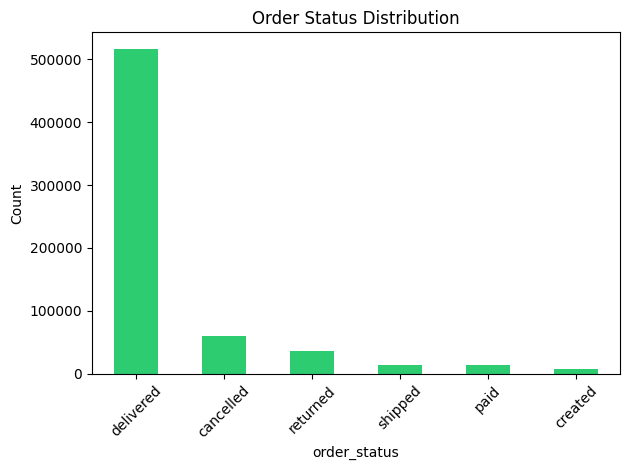

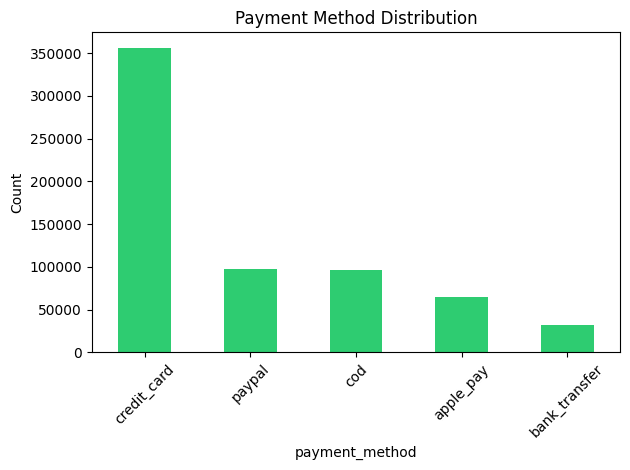

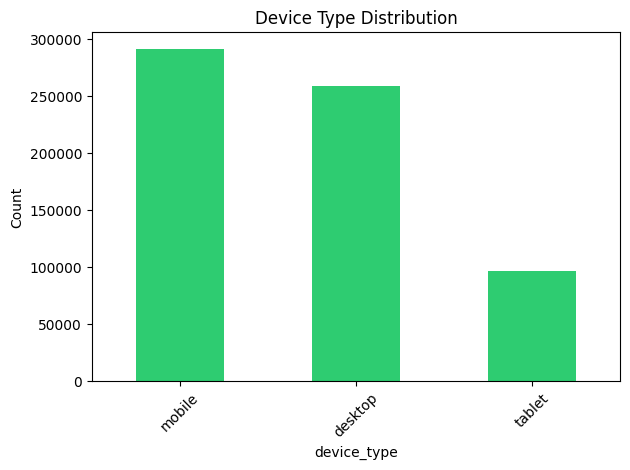

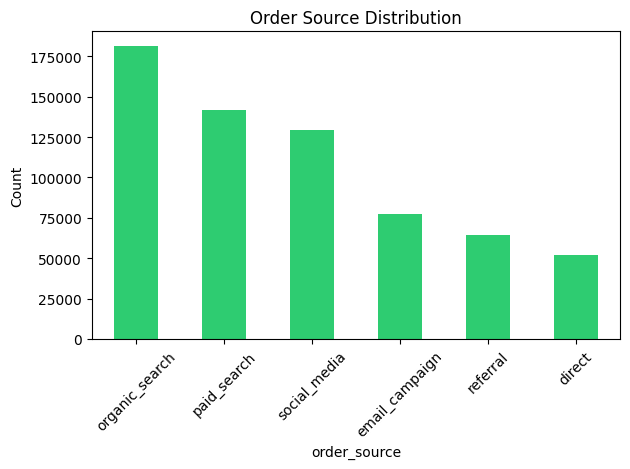

In [ ]:
# VẼ BIỂU ĐỒ DISTRUBUTION CỦA CÁC BIẾN PHÂN LOẠI
# Hàm vẽ biểu đồ
def plot_bar(series, title):
    plt.figure()
    series.plot(kind='bar', color='#2ecc71')  # xanh lá đẹp
    plt.title(title)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Vẽ biểu đồ
plot_bar(orders['order_status'].value_counts(), "Order Status Distribution")
plot_bar(orders['payment_method'].value_counts(), "Payment Method Distribution")
plot_bar(orders['device_type'].value_counts(), "Device Type Distribution")
plot_bar(orders['order_source'].value_counts(), "Order Source Distribution")

In [ ]:
# XUẤT FILE SAU KHI XỬ LÝ: 'cleaned_orders.csv'
orders.to_csv('cleaned_orders.csv', index=False)

# **2. order_items**

In [3]:
# ĐỌC FILE order_items.csv
order_items = pd.read_csv('order_items.csv')

/tmp/ipykernel_10728/3712930485.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('order_items.csv')


In [4]:
# HIỂN THỊ 5 DÒNG ĐẦU TIÊN
display(order_items.head())

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN


In [5]:
# THÔNG TIN CÁC CỘT
display(order_items.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         714669 non-null  int64  
 1   product_id       714669 non-null  int64  
 2   quantity         714669 non-null  int64  
 3   unit_price       714669 non-null  float64
 4   discount_amount  714669 non-null  float64
 5   promo_id         276316 non-null  object 
 6   promo_id_2       206 non-null     object 
dtypes: float64(2), int64(3), object(2)
memory usage: 38.2+ MB


None

**DESCRIPTION:** CHI TIẾT ĐƠN HÀNG
| Cột              | Kiểu  | Mô tả                                                                 |
|------------------|-------|----------------------------------------------------------------------|
| order_id         | int   | FK → orders.order_id                                                 |
| product_id       | int   | FK → products.product_id                                             |
| quantity         | int   | Số lượng sản phẩm đặt mua      **(numeric)**                                      |
| unit_price       | float | Đơn giá      **(numeric)**                                                        |
| discount_amount  | float | Tổng số tiền giảm giá cho dòng sản phẩm này     **(numeric)**                     |
| promo_id         | str   | FK → promotions.promo_id (nullable)                                  |
| promo_id_2       | str   | FK → promotions.promo_id, khuyến mãi thứ hai (nullable)              |

In [ ]:
# THỐNG KÊ MÔ TẢ CÁC CỘT
print("THỐNG KÊ MÔ TẢ CÁC CỘT")
display(order_items.describe())

THỐNG KÊ MÔ TẢ CÁC CỘT


,order_id,product_id,quantity,unit_price,discount_amount
count,714669.000000,714669.000000,714669.000000,714669.000000,714669.000000
mean,411615.076561,1234.931370,4.495988,5114.690157,1048.887415
std,240480.310686,691.332564,2.290143,3774.817912,2280.530606
min,1.000000,1.000000,1.000000,392.570000,0.000000
25%,203229.000000,689.000000,2.000000,1906.890000,0.000000
50%,409306.000000,990.000000,4.000000,4257.770000,0.000000
75%,618981.000000,2045.000000,6.000000,7273.760000,967.630000
max,834397.000000,2412.000000,8.000000,43056.000000,35235.470000


In [6]:
# KIỂM TRA DUPLICATE
print("THÔNG TIN DUPLICATE:")
display(order_items.duplicated().sum())

THÔNG TIN DUPLICATE:


np.int64(0)

In [ ]:
# KIỂM TRA MISSING VALUE
print("THÔNG TIN MISSING VALUE:")
display(order_items.isnull().sum())

THÔNG TIN MISSING VALUE:


,0
order_id,0
product_id,0
quantity,0
unit_price,0
discount_amount,0
promo_id,438353
promo_id_2,714463


**REMARKS**
- `'promo_id', 'promo_id_2'` có số lượng null rất lớn.
- Tuy nhiên, giá trị null ở đây là hợp lý vì `không phải đơn nào cũng có khuyến mãi.`
- promo_id_2 missing nhiều hơn → `khuyến mãi thứ 2 ít được sử dụng hơn.`

In [ ]:
# KIỂM TRA LOGIC:

# 1. CHECK CÓ DÒNG NÀO quantity < 0 KHÔNG?
print("CHECK CÓ DÒNG NÀO quantity < 0 KHÔNG?")
display(order_items[order_items['quantity'] < 0])

# 2. CHECK CÓ DÒNG NÀO unit_price < 0 không?
print("\nCHECK CÓ DÒNG NÀO unit_price < 0 không?")
display(order_items[order_items['unit_price'] < 0])

# 3. CHECK CÓ DÒNG NÀO discount_amount > unit_price * quantity (giảm giá vô lý) KHÔNG?
print("\nCHECK CÓ DÒNG NÀO discount_amount > unit_price * quantity (giảm giá vô lý) KHÔNG?")
display(order_items[order_items['discount_amount'] > order_items['unit_price'] * order_items['quantity']])

CHECK CÓ DÒNG NÀO quantity < 0 KHÔNG?


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2



CHECK CÓ DÒNG NÀO unit_price < 0 không?


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2



CHECK CÓ DÒNG NÀO discount_amount > unit_price * quantity (giảm giá vô lý) KHÔNG?


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2


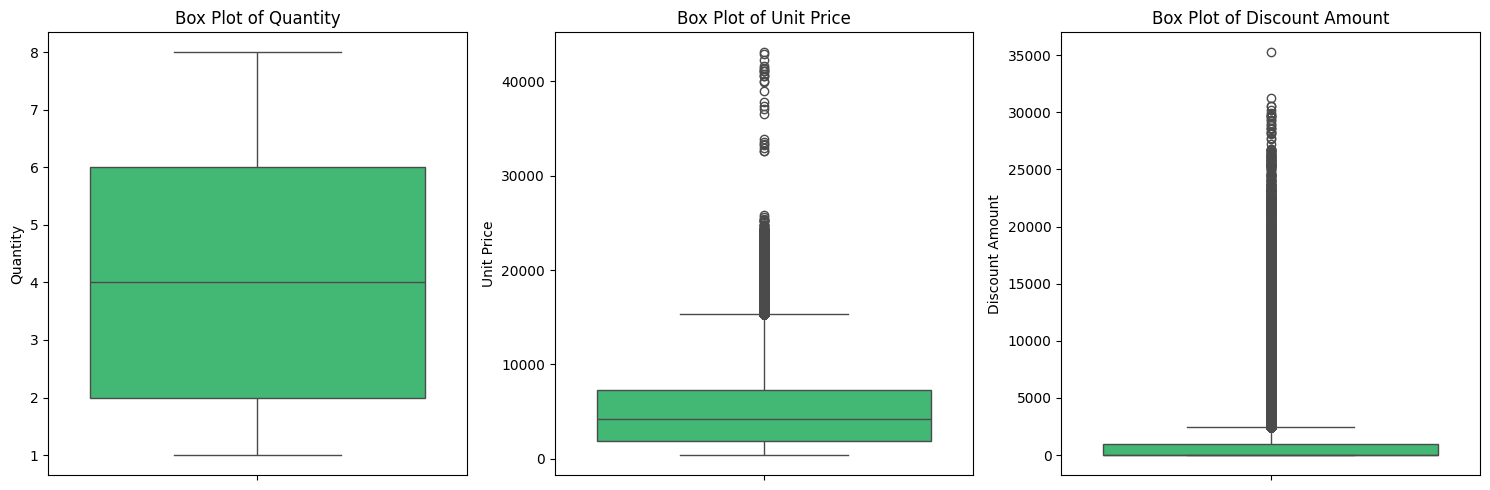

In [ ]:
# VẼ BOX PLOT CÁC CỘT NUMERIC: 'quantity', 'unit_price', 'discount_amount'

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.boxplot(y=order_items['quantity'], color = '#2ecc71')
plt.title('Box Plot of Quantity')
plt.ylabel('Quantity')

plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.boxplot(y=order_items['unit_price'], color = '#2ecc71')
plt.title('Box Plot of Unit Price')
plt.ylabel('Unit Price')

plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.boxplot(y=order_items['discount_amount'], color = '#2ecc71')
plt.title('Box Plot of Discount Amount')
plt.ylabel('Discount Amount')

plt.tight_layout()
plt.show()

**REMARKS**

1. **Quantity**

- Phân bố khá đều, `không có nhiều outlier`.
- Median ≈ 4 → khách thường mua 3–5 sản phẩm/đơn.
- Khoảng giá trị từ 1 → 8 → không có đơn quá lớn.

2. **Unit Price**

- `Lệch phải mạnh` (right-skewed).
- Có rất nhiều `outlier giá cao` (lên đến ~40k+).
- `Median thấp hơn nhiều so với max` → phần lớn sản phẩm giá trung bình–thấp, nhưng có một số `sản phẩm cao cấp.`

3. **Discount Amount**

- Cũng `lệch phải rất mạnh.`
- Phần lớn đơn có `discount thấp hoặc gần 0.`
- Tuy nhiên có nhiều outlier giảm giá rất lớn → có thể là:
    - `chương trình khuyến mãi lớn`
    - hoặc `đơn hàng giá trị cao`

>Tổng kết:
- Dữ liệu có xu hướng long-tail (đuôi dài bên phải) ở Unit Price và Discount
- Nên cân nhắc:
  - xử lý outlier
  - hoặc dùng log transformation khi modeling

In [ ]:
# XUÂT FILE SAU KHI XỬ LÝ 'cleaned_order_items.csv'
order_items.to_csv('cleaned_order_items.csv', index=False)

# **3. payments**

In [ ]:
# ĐỌC FILE payments.csv
payments = pd.read_csv('payments.csv')

In [ ]:
# HIỂN THỊ 5 DÒNG ĐẦU TIÊN
display(payments.head())

,order_id,payment_method,payment_value,installments
0,1,credit_card,7967.54,3
1,2,cod,71163.75,1
2,3,credit_card,33660.99,3
3,4,credit_card,53196.25,3
4,6,paypal,1597.84,1


In [ ]:
# THÔNG TIN CÁC CỘT
display(payments.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        646945 non-null  int64  
 1   payment_method  646945 non-null  object 
 2   payment_value   646945 non-null  float64
 3   installments    646945 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 19.7+ MB


None

**DESCRIPTION:** THANH TOÁN

| Cột             | Kiểu   | Mô tả                                                                 |
|-----------------|--------|----------------------------------------------------------------------|
| order_id        | int    | FK → orders.order_id (quan hệ 1:1 với bảng orders)                  |
| payment_method  | str    | Phương thức thanh toán         **(category)**                                     |
| payment_value   | float  | Tổng giá trị thanh toán của đơn hàng      **(numeric)**                          |
| installments    | int    | Số kỳ trả góp       **(numeric)**                                               |

In [ ]:
# THỐNG KÊ MÔ TẢ CÁC CỘT
print("THỐNG KÊ MÔ TẢ CÁC CỘT")
display(payments.describe())

THỐNG KÊ MÔ TẢ CÁC CỘT


,order_id,payment_value,installments
count,646945.000000,646945.000000,646945.000000
mean,417189.470332,24238.334426,3.448319
std,240785.704463,22378.475324,3.119582
min,1.000000,389.740000,1.000000
25%,208728.000000,7681.060000,1.000000
50%,417211.000000,17229.440000,3.000000
75%,625628.000000,33706.350000,6.000000
max,834397.000000,331570.400000,12.000000


In [ ]:
# KIỂM TRA DUPLICATE
print("THÔNG TIN DUPLICATE:")
display(payments.duplicated().sum())

print("\n KIỂM TRA CÓ DUPLICATE order_id không?")
display(payments['order_id'].duplicated().sum())

THÔNG TIN DUPLICATE:


np.int64(0)


 KIỂM TRA CÓ DUPLICATE order_id không?


np.int64(0)

In [ ]:
# KIỂM TRA MISSING VALUE
print("THÔNG TIN MISSING VALUE:")
display(payments.isnull().sum())

THÔNG TIN MISSING VALUE:


,0
order_id,0
payment_method,0
payment_value,0
installments,0


In [ ]:
# KIỂM TRA LOGIC:

# 1. CHECK CÓ DÒNG NÀO payment_value < 0 KHÔNG?
print("CHECK CÓ DÒNG NÀO payment_value < 0 KHÔNG?")
display(payments[payments['payment_value'] < 0])

# 2. CHECK CÓ DÒNG NÀO installments < 1 không?
print("\nCHECK CÓ DÒNG NÀO installments < 1 không?")
display(payments[payments['installments'] < 1])

CHECK CÓ DÒNG NÀO payment_value < 0 KHÔNG?


,order_id,payment_method,payment_value,installments



CHECK CÓ DÒNG NÀO installments < 1 không?


,order_id,payment_method,payment_value,installments


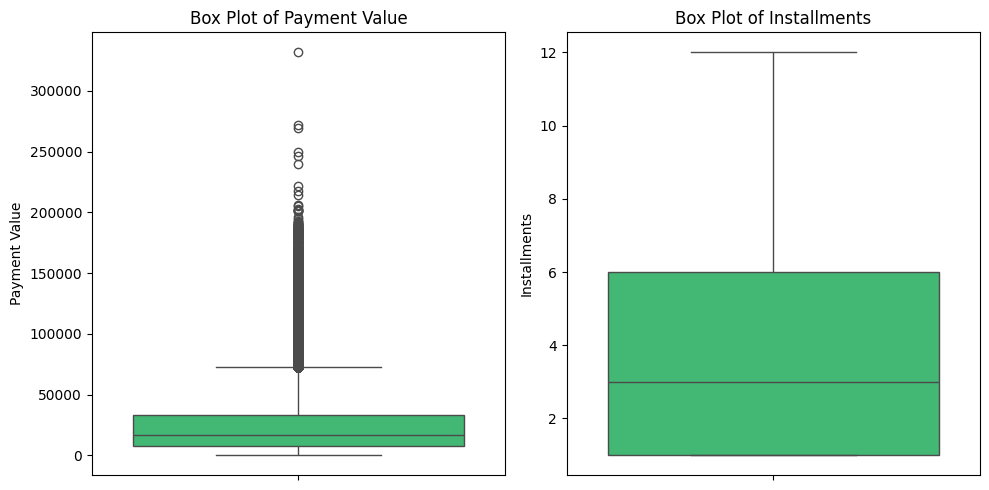

In [ ]:
# VẼ BOX PLOT CÁC CỘT NUMERIC: 'payment_value', 'installments'

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.boxplot(y=payments['payment_value'], color = '#2ecc71')
plt.title('Box Plot of Payment Value')
plt.ylabel('Payment Value')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=payments['installments'], color = '#2ecc71')
plt.title('Box Plot of Installments')
plt.ylabel('Installments')

plt.tight_layout()
plt.show()

**REMARKS**

1. **Payment Value**
- Phân phối **lệch phải rất mạnh (right-skewed)**.
- Phần lớn giao dịch có giá trị **thấp (< 50,000)** → tập trung ở đáy boxplot.
- Xuất hiện **nhiều outliers lớn (75,000 → >300,000)** → tồn tại các đơn hàng giá trị cao.
- Median thấp → hành vi mua phổ biến là **đơn hàng nhỏ**.

> **Nhận định:**
- Dữ liệu mang đặc trưng **long-tail distribution** (phổ biến trong e-commerce).
- Doanh thu có thể phụ thuộc vào **một số ít đơn hàng lớn**.

---

2. **Installments**
- Phân phối khá **cân đối, không có outlier bất thường**.
- Giá trị nằm trong khoảng **1 → 12 kỳ**.
- Median = **3 kỳ** → lựa chọn phổ biến nhất.
- 75% dữ liệu nằm trong khoảng **1–6 kỳ**.

> **Nhận định:**
- Khách hàng chủ yếu chọn **trả góp ngắn hạn**.
- Số kỳ trả góp có thể bị giới hạn bởi **business rule**.

---

3. **Insight tổng hợp**
- Khách hàng thường:
  - Mua **đơn hàng giá trị thấp**
  - Chọn **ít kỳ trả góp (≈ 3 kỳ)**
- Một số ít đơn hàng giá trị cao tạo ra **đuôi dài trong phân phối**.

---

4. **Data & Modeling Considerations**
- `payment_value` có nhiều outlier → cần xử lý khi modeling:
  - Log Transformation (`log1p`)
  - hoặc capping (P99)
- `installments` là biến rời rạc → có thể dùng trực tiếp

---

5. **Gợi ý hướng phân tích tiếp theo**
- Kiểm tra mối quan hệ giữa:
  - `payment_value` và `installments`
- Tạo thêm feature:
  - `payment_segment` (low / medium / high)
- Đánh giá:
  - ảnh hưởng của giá trị đơn hàng đến hành vi trả góp

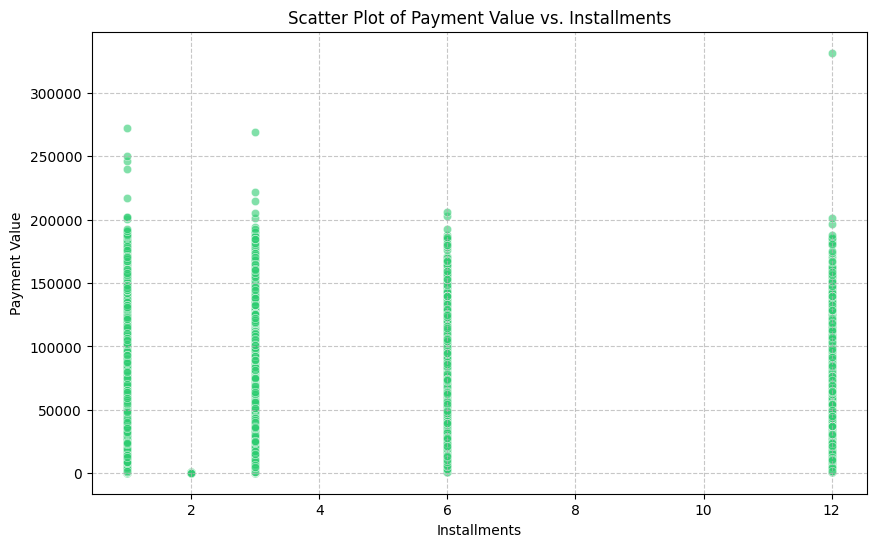

In [ ]:
# VẼ SCATTER PLOT KIỂM TRA MỐI QUAN HỆ GIỮA payment_value và installments
plt.figure(figsize=(10, 6))
sns.scatterplot(x='installments', y='payment_value', data=payments, alpha=0.6, color = '#2ecc71')
plt.title('Scatter Plot of Payment Value vs. Installments')
plt.xlabel('Installments')
plt.ylabel('Payment Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**REMARKS:** MỐI QUAN HỆ GIỮA payment_value và installments

1. **Không có mối quan hệ rõ ràng (weak relationship)**
- Các điểm dữ liệu **phân tán theo chiều dọc** ở mỗi mức installments **(1, 3, 6, 12)**
- `Không thấy xu hướng: installments ↑ → payment ↑ (KHÔNG rõ)`

→ **Correlation rất yếu hoặc gần 0**

2. **Installments là biến rời rạc (discrete)**
- Chỉ xuất hiện ở các giá trị: 1, 3, 6, 12 → **Đây là business rule, không phải biến liên tục**

3. **Outlier xuất hiện ở mọi mức installments**
- Các điểm giá trị cao (~200k–330k) xuất hiện ở:
  - cả 1 kỳ
  - cả 12 kỳ

→ `đơn hàng lớn không phụ thuộc hoàn toàn vào trả góp`

4. **Hành vi khách hàng thú vị**
- Có khách: `mua giá trị cao nhưng vẫn trả 1 lần (installment = 1)`

→ chứng tỏ:
- không phải ai mua đắt cũng cần trả góp
- yếu tố tài chính / preference rất khác nhau

>**INSIGHT**:

`Không tồn tại mối quan hệ tuyến tính rõ ràng giữa giá trị thanh toán và số kỳ trả góp. Điều này cho thấy quyết định sử dụng trả góp không chỉ phụ thuộc vào giá trị đơn hàng mà còn bị ảnh hưởng bởi các yếu tố hành vi hoặc tài chính cá nhân của khách hàng.`




In [ ]:
# VALUE_COUNT CÁC CỘT PHÂN LOẠI: 'payment_method'
print("VALUE_COUNT CỘT PHÂN LOẠI: 'payment_method'")
display(payments['payment_method'].value_counts())

VALUE_COUNT CỘT PHÂN LOẠI: 'payment_method'


,count
payment_method,
credit_card,356352
paypal,97018
cod,96681
apple_pay,64763
bank_transfer,32131


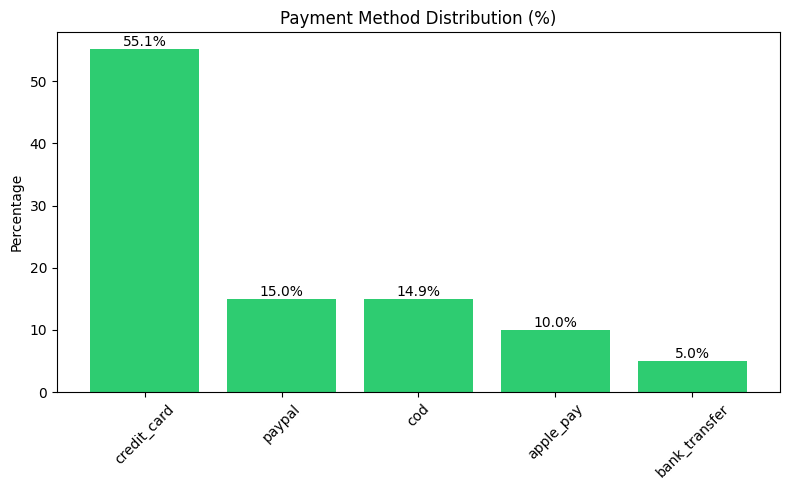

In [ ]:
# VẼ BIỂU ĐỒ DISTRUBUTION BIẾN PHÂN LOẠI payment_method
payment_pct = payments['payment_method'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
plt.bar(payment_pct.index, payment_pct.values, color='#2ecc71')
plt.title("Payment Method Distribution (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

for i, v in enumerate(payment_pct.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

**GIẢI THÍCH ĐỊNH NGHĨA CÁC PAYMENT METHOD**

**1. Credit Card (Thẻ tín dụng)**: Là hình thức thanh toán bằng thẻ ngân hàng cho phép **chi tiêu trước – trả tiền sau**.

**2. Paypal**: Là **ví điện tử quốc tế**, cho phép thanh toán online mà không cần nhập thông tin thẻ trực tiếp.

**3. COD (Cash On Delivery – Thanh toán khi nhận hàng)**: Khách hàng **trả tiền mặt khi nhận hàng**.

**4. Apple Pay**: - Là hình thức thanh toán qua **thiết bị Apple (iPhone, Apple Watch)** bằng ví điện tử.

**5. Bank Transfer (Chuyển khoản ngân hàng)**: Khách hàng **chuyển tiền trực tiếp từ tài khoản ngân hàng**.

**REMARKS**

**1. Sự thống trị của Credit Card**
- Credit Card là phương thức thanh toán phổ biến nhất (**~55.1%**).
- Tỷ lệ này **lớn hơn tổng các phương thức còn lại cộng lại**.
  
> **Nhận định:**
- Khách hàng có xu hướng **thanh toán không tiền mặt cao**.
- Có thể do:
  - Ưu đãi từ thẻ
  - Trải nghiệm thanh toán nhanh và tiện lợi

---

**2. Sự cân bằng giữa Paypal và COD**
- Paypal (**~15.0%**) và COD (**~14.9%**) gần như tương đương.

> **Nhận định:**
- COD vẫn chiếm tỷ trọng đáng kể → một nhóm khách hàng:
  - ưu tiên **an toàn**
  - chưa hoàn toàn tin tưởng thanh toán online
- Paypal đại diện cho nhóm khách hàng **quen thuộc với thanh toán số**

---

**3. Nhóm phương thức hiện đại và truyền thống**
- Apple Pay (**~10.0%**): đang phát triển mạnh trong thanh toán di động
- Bank Transfer (**~5.0%**): thấp nhất do:
  - quy trình chậm
  - ít tiện lợi hơn các phương thức tự động

---

> **Insight kinh doanh**

- Hệ thống có xu hướng **digital-first** (ưu tiên thanh toán online)
- Tuy nhiên vẫn tồn tại **phân khúc khách hàng truyền thống (COD)**
- Hành vi thanh toán **đa dạng**, cần hỗ trợ nhiều phương thức


In [ ]:
# XUẤT FILE SAU KHI XỬ LÝ 'cleaned_payments.csv'
payments.to_csv('cleaned_payments.csv', index=False)

# **4. shipments**

In [ ]:
# ĐỌC FILE shipments.csv
shipments = pd.read_csv('shipments.csv')

In [ ]:
# HIỂN THỊ 5 DÒNG ĐẦU TIÊN
display(shipments.head())

,order_id,ship_date,delivery_date,shipping_fee
0,1,2012-07-07,2012-07-11,1.37
1,2,2012-07-06,2012-07-10,2.60
2,3,2012-07-04,2012-07-07,2.38
3,4,2012-07-05,2012-07-11,2.49
4,6,2012-07-09,2012-07-16,25.79


In [ ]:
# THÔNG TIN CÁC CỘT
display(shipments.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566067 entries, 0 to 566066
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_id       566067 non-null  int64  
 1   ship_date      566067 non-null  object 
 2   delivery_date  566067 non-null  object 
 3   shipping_fee   566067 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 17.3+ MB


None

In [ ]:
# CONVERT DATATYPE CỘT ship_date, delivery_date sang dạng DATATIME
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'])
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])
shipments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566067 entries, 0 to 566066
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   order_id       566067 non-null  int64         
 1   ship_date      566067 non-null  datetime64[ns]
 2   delivery_date  566067 non-null  datetime64[ns]
 3   shipping_fee   566067 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(1)
memory usage: 17.3 MB


**DESCRIPTION:** VẬN CHUYỂN
| Cột            | Kiểu   | Mô tả                                                                 |
|----------------|--------|----------------------------------------------------------------------|
| order_id       | int    | FK → orders.order_id                                                 |
| ship_date      | date   | Ngày gửi hàng                                                        |
| delivery_date  | date   | Ngày giao hàng đến tay khách                                         |
| shipping_fee   | float  | Phí vận chuyển (0 nếu đơn được miễn phí)      **(numeric)**                       |     |

> `Chỉ tồn tại cho đơn hàng có trạng thái shipped, delivered hoặc returned.`

In [ ]:
# THỐNG KÊ MÔ TẢ CÁC CỘT
print("THỐNG KÊ MÔ TẢ CÁC CỘT")
display(shipments.describe())

THỐNG KÊ MÔ TẢ CÁC CỘT


,order_id,ship_date,delivery_date,shipping_fee
count,566067.000000,566067,566067,566067.000000
mean,415816.869664,2016-11-22 15:48:56.813486336,2016-11-27 03:47:48.510618112,4.962857
min,1.000000,2012-07-04 00:00:00,2012-07-06 00:00:00,0.000000
25%,208192.500000,2014-08-05 00:00:00,2014-08-10 00:00:00,0.870000
50%,415866.000000,2016-07-22 00:00:00,2016-07-27 00:00:00,1.730000
75%,623218.500000,2018-08-17 00:00:00,2018-08-22 00:00:00,2.600000
max,834325.000000,2022-12-29 00:00:00,2022-12-31 00:00:00,32.000000
std,240007.311562,NaN,NaN,8.887355


In [ ]:
# KIỂM TRA DUPLICATE
print("THÔNG TIN DUPLICATE:")
display(shipments.duplicated().sum())

print("\nKIỂM TRA CÓ DUPLICATE order_id không?")
display(shipments['order_id'].duplicated().sum())

THÔNG TIN DUPLICATE:


np.int64(0)


KIỂM TRA CÓ DUPLICATE order_id không?


np.int64(0)

In [ ]:
# KIỂM TRA MISSING VALUE
print("THÔNG TIN MISSING VALUE:")
display(shipments.isnull().sum())

THÔNG TIN MISSING VALUE:


,0
order_id,0
ship_date,0
delivery_date,0
shipping_fee,0


In [ ]:
# KIỂM TRA LOGIC:


# 1. CHECK CÓ DÒNG NÀO shipping_fee < 0 KHÔNG?
print("CHECK CÓ DÒNG NÀO shipping_fee < 0 KHÔNG?")
display(shipments[shipments['shipping_fee'] < 0])


# 2. CHECK CÓ DÒNG NÀO delivery_date < ship_date không?
print("\nCHECK CÓ DÒNG NÀO delivery_date < ship_date không?")
display(shipments[shipments['delivery_date'] < shipments['ship_date']])


# 3. KIỂM TRA LOGIC : "Chỉ tồn tại cho đơn hàng có trạng thái shipped, delivered hoặc returned trong bảng shipments."
# Join orders + shipping
orders_shipments = orders.merge(
    shipments,
    on='order_id',
    how='inner'
)
# Tìm các dòng shipping nhưng status KHÔNG hợp lệ
invalid = orders_shipments[
    ~orders_shipments['order_status'].isin(['shipped', 'delivered', 'returned'])
]
print("Số dòng vi phạm:", len(invalid))
invalid.head()



CHECK CÓ DÒNG NÀO shipping_fee < 0 KHÔNG?


,order_id,ship_date,delivery_date,shipping_fee



CHECK CÓ DÒNG NÀO delivery_date < ship_date không?


,order_id,ship_date,delivery_date,shipping_fee


Số dòng vi phạm: 0


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,ship_date,delivery_date,shipping_fee


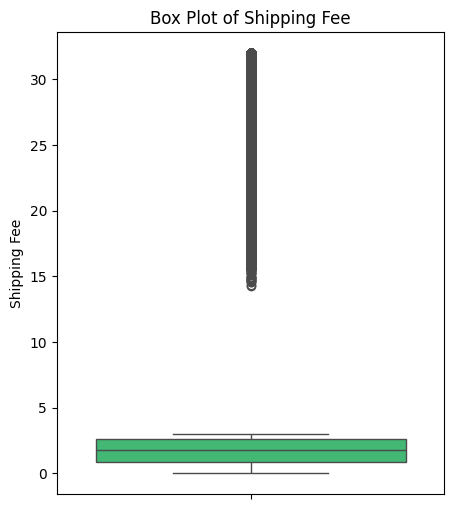

In [ ]:
# VẼ BOX PLOT CỘT NUMERIC: 'shipping_fee'
plt.figure(figsize=(5, 6))
sns.boxplot(y=shipments['shipping_fee'], color = '#2ecc71')
plt.title('Box Plot of Shipping Fee')
plt.ylabel('Shipping Fee')
plt.show()

**REMARKS**: PHÂN PHỐI CỘT shipping_fee

**1. Phân phối dữ liệu (Distribution)**
- Phí vận chuyển tập trung ở mức **rất thấp**, phần lớn nằm trong khoảng **1–3**.
- IQR nằm sát trục hoành → cho thấy dữ liệu **tập trung mạnh ở giá trị nhỏ**.
- Median ≈ **1.8 – 2** → 50% đơn hàng có phí ship thấp hơn mức này.

>**Nhận định:**
- Đa số đơn hàng thuộc nhóm **phí vận chuyển rẻ, ổn định**.

---

**2. Hiện tượng Outliers**
- Xuất hiện nhiều outliers từ khoảng **14 → >30**.
- Có khoảng cách lớn giữa nhóm chính (<5) và nhóm outlier (>14).

> **Nhận định:**
- Dữ liệu chia thành 2 nhóm rõ rệt:
  - **Nhóm phổ thông:** phí thấp, ổn định  
  - **Nhóm đặc biệt:** phí cao (hàng cồng kềnh, giao nhanh, vùng xa,...)

---

**3. Đánh giá chất lượng dữ liệu (Data Quality)**
- Phân phối **lệch phải rất mạnh (positive skew)**.
- Outliers có thể:
  - Là dữ liệu hợp lệ (business case đặc biệt)
  - Hoặc gây nhiễu khi modeling

---

**Thách thức khi sử dụng trong mô hình**
- Các giá trị lớn (15–30) có thể:
  - Làm lệch phân phối
  - Ảnh hưởng mạnh đến các model nhạy với khoảng cách

---

**Hướng xử lý đề xuất**
- Kiểm tra tỷ lệ outlier:
  - Nếu rất nhỏ → có thể xử lý
- Các phương pháp:
  - **Log Transformation** (`log1p`)
  - **Winsorization / Capping (P99)**
- Hoặc:
  - Tạo biến phân nhóm (low / high shipping fee)

In [ ]:
# XUÂT FILE SAU KHI XỬ LÝ 'cleaned_shipments.csv'
shipments.to_csv('cleaned_shipments.csv', index=False)

# **5. returns**

In [ ]:
# ĐỌC FILE returns.csv
returns = pd.read_csv('returns.csv')

In [ ]:
# HIỂN THỊ 5 DÒNG ĐẦU TIÊN
display(returns.head())

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76


In [ ]:
# THÔNG TIN CÁC CỘT
display(returns.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   return_id        39939 non-null  object 
 1   order_id         39939 non-null  int64  
 2   product_id       39939 non-null  int64  
 3   return_date      39939 non-null  object 
 4   return_reason    39939 non-null  object 
 5   return_quantity  39939 non-null  int64  
 6   refund_amount    39939 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 2.1+ MB


None

In [ ]:
# CONVERT DATATYPE CỘT return_date sang dạng DATATIME
returns['return_date'] = pd.to_datetime(returns['return_date'])
display(returns.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   return_id        39939 non-null  object        
 1   order_id         39939 non-null  int64         
 2   product_id       39939 non-null  int64         
 3   return_date      39939 non-null  datetime64[ns]
 4   return_reason    39939 non-null  object        
 5   return_quantity  39939 non-null  int64         
 6   refund_amount    39939 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 2.1+ MB


None

**DESCRIPTION:** TRẢ HÀNG
| Cột              | Kiểu   | Mô tả                                                                 |
|------------------|--------|----------------------------------------------------------------------|
| return_id        | str    | Khoá chính                                                           |
| order_id         | int    | FK → orders.order_id                                                 |
| product_id       | int    | FK → products.product_id                                             |
| return_date      | date   | Ngày khách gửi trả hàng                                              |
| return_reason    | str    | Lý do trả hàng     **(category)**                                                  |
| return_quantity  | int    | Số lượng sản phẩm trả lại     **(numeric)**                                       |
| refund_amount    | float  | Số tiền hoàn lại cho khách    **(numeric)**                                       |

In [ ]:
# THỐNG KÊ MÔ TẢ CÁC CỘT
print("THỐNG KÊ MÔ TẢ CÁC CỘT")
display(returns.describe())

THỐNG KÊ MÔ TẢ CÁC CỘT


,order_id,product_id,return_date,return_quantity,refund_amount
count,39939.000000,39939.000000,39939,39939.000000,39939.000000
mean,409061.984176,1244.232730,2016-11-11 22:20:33.621272576,2.743834,12784.458964
min,2.000000,3.000000,2012-07-11 00:00:00,1.000000,458.810000
25%,202651.000000,702.000000,2014-08-05 00:00:00,1.000000,3573.395000
50%,404254.000000,992.000000,2016-07-06 00:00:00,2.000000,7888.880000
75%,615620.000000,2048.000000,2018-08-08 00:00:00,4.000000,16881.990000
max,833351.000000,2412.000000,2022-12-31 00:00:00,8.000000,160937.940000
std,240063.904576,691.747822,NaN,1.828260,14092.150154


In [ ]:
# KIỂM TRA DUPLICATE
print("THÔNG TIN DUPLICATE:")
display(returns.duplicated().sum())

THÔNG TIN DUPLICATE:


np.int64(0)

In [ ]:
# KIỂM TRA MISSING VALUE
print("THÔNG TIN MISSING VALUE:")
display(returns.isnull().sum())

THÔNG TIN MISSING VALUE:


,0
return_id,0
order_id,0
product_id,0
return_date,0
return_reason,0
return_quantity,0
refund_amount,0


In [ ]:
# KIỂM TRA LOGIC:

# 1. CHECK CÓ DÒNG NÀO return_quantity <= 0 KHÔNG?
print("CHECK CÓ DÒNG NÀO return_quantity <= 0 KHÔNG?")
display(returns[returns['return_quantity'] <= 0])

# 2. CHECK CÓ DÒNG NÀO refund_amount < 0 không?
print("\nCHECK CÓ DÒNG NÀO refund_amount < 0 không?")
display(returns[returns['refund_amount'] < 0])



CHECK CÓ DÒNG NÀO return_quantity <= 0 KHÔNG?


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount



CHECK CÓ DÒNG NÀO refund_amount < 0 không?


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount


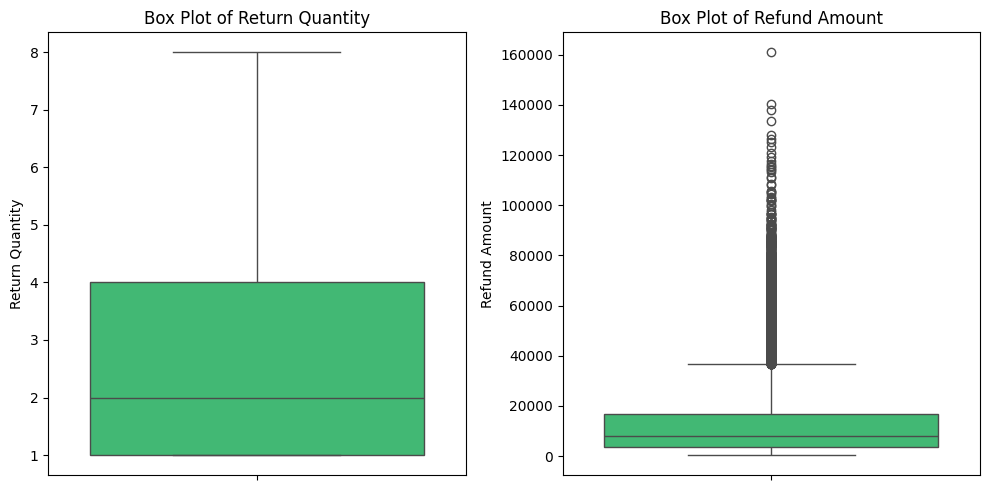

In [ ]:
# VẼ BOX PLOT CÁC CỘT NUMERIC: 'return_quantity', 'refund_amount'
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.boxplot(y=returns['return_quantity'], color = '#2ecc71')
plt.title('Box Plot of Return Quantity')
plt.ylabel('Return Quantity')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=returns['refund_amount'], color = '#2ecc71')
plt.title('Box Plot of Refund Amount')
plt.ylabel('Refund Amount')

plt.tight_layout()
plt.show()

**REMARKS:** Returns Analysis: Return Quantity & Refund Amount

**1. Return Quantity (Số lượng hàng trả)**
- Phân phối **ổn định, không có outlier**.
- Giá trị dao động từ **1 → 8 sản phẩm**.
- Median = **2** → phần lớn đơn trả chỉ gồm **1–2 sản phẩm**.
- 75% dữ liệu ≤ **4 sản phẩm**.

>**Nhận định:**
- Hành vi trả hàng thường ở quy mô **nhỏ, kiểm soát được**.
- Dữ liệu sạch, phản ánh đúng giới hạn nghiệp vụ.

---

**2. Refund Amount (Số tiền hoàn lại)**
- Phân phối **lệch phải rất mạnh (right-skewed)**.
- Median ≈ **8,000** → đa số hoàn tiền giá trị thấp.
- Xuất hiện nhiều **outliers lớn (40,000 → 160,000)**.

> **Nhận định:**
- Một số ít sản phẩm có giá trị cao gây ra **khoản hoàn tiền lớn**.
- Phân phối mang đặc trưng **long-tail**.

---

**Insight tổng hợp**
- Số tiền hoàn lại **phụ thuộc nhiều vào giá trị sản phẩm** hơn là số lượng.
- Một sản phẩm giá cao có thể tạo ra refund lớn hơn nhiều so với nhiều sản phẩm giá thấp.

---

**Rủi ro kinh doanh**
- Nhóm refund cao (outliers) có thể:
  - Ảnh hưởng lớn đến **doanh thu và lợi nhuận**
  - Cần được theo dõi riêng

---

**Hướng phân tích tiếp theo**
- Tạo biến:
  - `refund_per_item = refund_amount / return_quantity`
- Phân tích:
  - Nhóm sản phẩm có **refund cao**
  - Tỷ lệ hoàn trả theo **product/category**
- Kiểm tra:
  - Có sản phẩm nào **giá cao nhưng bị trả nhiều không**

---

**Kết luận**
- Return Quantity ổn định → hành vi trả hàng nhỏ lẻ.
- Refund Amount có phân phối lệch phải → tồn tại nhóm sản phẩm giá trị cao cần kiểm soát.
- Cần phân tích sâu hơn theo **giá trị sản phẩm** để tối ưu kinh doanh.

In [ ]:
# VALUE_COUNT CỘT PHÂN LOẠI: 'return_reasom'
print("VALUE_COUNT CỘT PHÂN LOẠI: 'return_reason'")
display(returns['return_reason'].value_counts())

VALUE_COUNT CỘT PHÂN LOẠI: 'return_reason'


,count
return_reason,
wrong_size,13967
defective,8020
not_as_described,7035
changed_mind,6931
late_delivery,3986


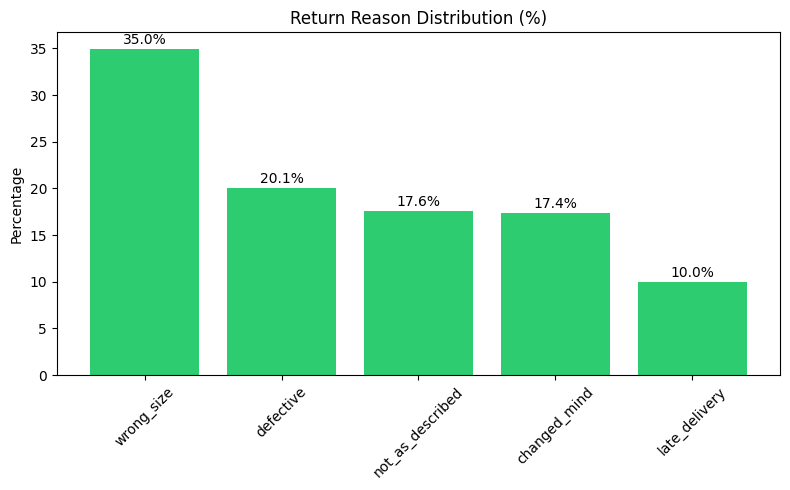

In [ ]:
# VẼ BIỂU ĐỒ DISTRUBUTION BIẾN PHÂN LOẠI return reason
return_pct = returns['return_reason'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
plt.bar(return_pct.index, return_pct.values, color='#2ecc71')
plt.title("Return Reason Distribution (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

for i, v in enumerate(return_pct.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

**REMARKS:** Return Reason

**Tổng quan**
- Trả hàng chủ yếu đến từ 3 nhóm chính:
  - **wrong_size (35%)** – cao nhất
  - **defective & not_as_described (~38%)** – từ phía doanh nghiệp
  - **changed_mind & late_delivery (~27%)**

---

**Insight chính**
- **Wrong Size (35%)**:
  - Nguyên nhân lớn nhất → vấn đề thông tin sản phẩm (size, fit)

- **Defective (20.1%) + Not as described (17.6%)**:
  - Gần **40%** → lỗi nội bộ:
    - chất lượng sản phẩm
    - hình ảnh/mô tả chưa chính xác

- **Changed mind (17.4%)**:
  - Hành vi khách hàng → khó kiểm soát

- **Late delivery (10%)**:
  - Ảnh hưởng từ logistics

---

**Tác động kinh doanh**
- Tăng:
  - chi phí vận chuyển 2 chiều
  - chi phí xử lý hàng trả
- Nếu kết hợp với **refund cao** → ảnh hưởng lớn đến lợi nhuận

---

**Hành động đề xuất**
- **Giảm sai size:**
  - Size chart chi tiết, gợi ý size

- **Cải thiện mô tả:**
  - Ảnh thật, video, mô tả chính xác

- **Kiểm soát chất lượng:**
  - Siết QC trước khi giao

- **Tối ưu giao hàng:**
  - Giảm delay

---

In [ ]:
# XUÂT FILE SAU KHI XỬ LÝ 'cleaned_returns.csv'
returns.to_csv('cleaned_returns.csv', index=False)

# **6. reviews**

In [ ]:
# ĐỌC FILE reviews.csv
reviews = pd.read_csv('reviews.csv')

In [ ]:
# HIỂN THỊ 5 DÒNG ĐẦU TIÊN
display(reviews.head())

,review_id,order_id,product_id,customer_id,review_date,rating,review_title
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall


In [ ]:
# THÔNG TIN CÁC CỘT
display(reviews.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113551 entries, 0 to 113550
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   review_id     113551 non-null  object
 1   order_id      113551 non-null  int64 
 2   product_id    113551 non-null  int64 
 3   customer_id   113551 non-null  int64 
 4   review_date   113551 non-null  object
 5   rating        113551 non-null  int64 
 6   review_title  113551 non-null  object
dtypes: int64(4), object(3)
memory usage: 6.1+ MB


None

In [ ]:
# CONVERT DATATYPE CỘT review_date sang dạng DATATIME
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
display(reviews.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113551 entries, 0 to 113550
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   review_id     113551 non-null  object        
 1   order_id      113551 non-null  int64         
 2   product_id    113551 non-null  int64         
 3   customer_id   113551 non-null  int64         
 4   review_date   113551 non-null  datetime64[ns]
 5   rating        113551 non-null  int64         
 6   review_title  113551 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 6.1+ MB


None

**DESCRIPTION:** ĐÁNH GIÁ
| Cột            | Kiểu   | Mô tả                                                                 |
|----------------|--------|----------------------------------------------------------------------|
| review_id      | str    | Khoá chính                                                           |
| order_id       | int    | FK → orders.order_id                                                 |
| product_id     | int    | FK → products.product_id                                             |
| customer_id    | int    | FK → customers.customer_id                                           |
| review_date    | date   | Ngày khách gửi đánh giá                                              |
| rating         | int    | Điểm đánh giá từ 1 đến 5       **(numeric)**                                      |
| review_title   | str    | Tiêu đề đánh giá của khách hàng       **(category)**                               |

In [ ]:
reviews[reviews['product_id']==1562]

,review_id,order_id,product_id,customer_id,review_date,rating,review_title


In [ ]:
# THỐNG KÊ MÔ TẢ CÁC CỘT
print("THỐNG KÊ MÔ TẢ CÁC CỘT")
display(reviews.describe())

THỐNG KÊ MÔ TẢ CÁC CỘT


,order_id,product_id,customer_id,review_date,rating
count,113551.000000,113551.000000,113551.000000,113551,113551.000000
mean,408999.519740,1232.018705,85694.342762,2016-11-13 07:39:01.231693568,3.936011
min,1.000000,3.000000,2.000000,2012-07-10 00:00:00,1.000000
25%,202048.500000,689.000000,42096.000000,2014-08-07 00:00:00,3.000000
50%,406841.000000,981.000000,89755.000000,2016-07-14 00:00:00,4.000000
75%,614844.000000,2045.000000,133850.000000,2018-08-08 00:00:00,5.000000
max,833296.000000,2412.000000,157563.000000,2022-12-31 00:00:00,5.000000
std,239021.922809,690.839232,48501.480918,NaN,1.149867


In [ ]:
# KIỂM TRA DUPLICATE
print("THÔNG TIN DUPLICATE:")
display(reviews.duplicated().sum())

THÔNG TIN DUPLICATE:


np.int64(0)

In [ ]:
# KIỂM TRA MISSING VALUE
print("THÔNG TIN MISSING VALUE:")
display(reviews.isnull().sum())

THÔNG TIN MISSING VALUE:


,0
review_id,0
order_id,0
product_id,0
customer_id,0
review_date,0
rating,0
review_title,0


In [ ]:
# KIỂM TRA LOGIC:

# CHECK CÓ DÒNG NÀO rating nằm khoảng 1-5 KHÔNG?
print("CHECK CÓ DÒNG NÀO rating nằm khoảng 1-5 KHÔNG?")
display(reviews[~reviews['rating'].between(1,5)])

CHECK CÓ DÒNG NÀO rating nằm khoảng 1-5 KHÔNG?


,review_id,order_id,product_id,customer_id,review_date,rating,review_title


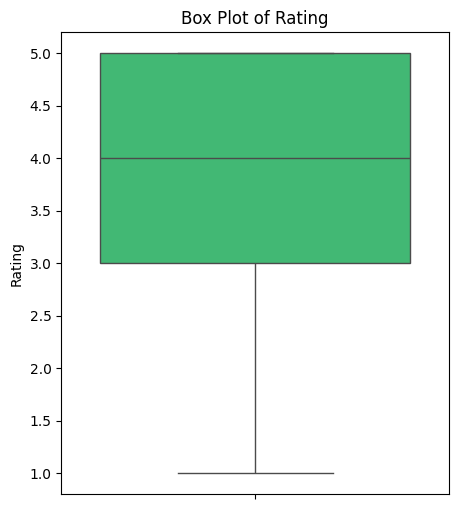

In [ ]:
# VẼ BOX PLOT CÁC CỘT NUMERIC: 'rating'
plt.figure(figsize=(5, 6))
sns.boxplot(y=reviews['rating'], color = '#2ecc71')
plt.title('Box Plot of Rating')
plt.ylabel('Rating')
plt.show()

**REMARKS:** Rating Distribution

- Giá trị rating nằm trong khoảng từ 1 đến 5, **không phát hiện giá trị ngoài phạm vi hợp lệ**  
  → Dữ liệu `tuân thủ đúng thang đo đánh giá`

- Trung vị (median) ≈ 4, và khoảng IQR từ 3 đến 5  
  → `Phần lớn đánh giá tập trung ở mức trung bình đến cao`

- Phân phối dữ liệu **lệch về phía điểm cao (đa số rating ≥ 3)**  
  → `Không có dấu hiệu phân phối bất thường hoặc sai lệch dữ liệu`

- **Không xuất hiện outlier rõ rệt**  
  → Các giá trị thấp (1–2) vẫn nằm trong phạm vi hợp lý của dữ liệu

- **Không phát hiện cụm giá trị bất thường hoặc khoảng trống dữ liệu lớn**  

=> `Dữ liệu rating hợp lệ, phân phối ổn định và không cần xử lý làm sạch thêm`

In [ ]:
# VALUE_COUNT CỘT PHÂN LOẠI: 'review_title'
print("VALUE_COUNT CỘT PHÂN LOẠI: 'review_title'")
display(reviews['review_title'].value_counts())

VALUE_COUNT CỘT PHÂN LOẠI: 'review_title'


,count
review_title,
Very satisfied,11450
Highly recommend,11407
Great quality,11218
Excellent product!,11181
Good overall,9185
Happy with purchase,9171
Solid choice,9070
Works well,8986
Mixed feelings,5706


**REMARKS:** Review Title

**1. Phân bố tổng thể (Overall Distribution)**

- Cột `review_title` bao gồm nhiều nhóm phân loại rõ ràng, với số lượng category ở mức hợp lý  
- Các giá trị có tần suất cao nhất:
  - Very satisfied (11,450)
  - Highly recommend (11,407)
  - Great quality (11,218)
  - Excellent product! (11,181)

- Các nhóm này có tần suất tương đương nhau, cho thấy `dữ liệu được phân bổ tương đối đồng đều ở nhóm đánh giá cao`  

---

**2. Nhóm giá trị trung bình (Mid-frequency Categories)**

- Các giá trị như:
  - Good overall (~9,185)
  - Happy with purchase (~9,171)
  - Solid choice (~9,070)
  - Works well (~8,986)

- Có tần suất **thấp hơn nhóm trên nhưng vẫn chiếm tỷ trọng đáng kể**  
→ Không có dấu hiệu bất thường trong phân phối

---

**3. Nhóm tần suất thấp hơn (Lower-frequency Categories)**

- Bao gồm:
  - Mixed feelings (~5,706)
  - Average product (~5,656)
  - Decent, nothing special (~5,654)

- Có sự **giảm rõ rệt về số lượng so với các nhóm phía trên**  
→ Tuy nhiên vẫn nằm trong phân phối hợp lý, không phải lỗi dữ liệu

---

**4. Nhóm tần suất thấp (Low-frequency Categories)**

- Các giá trị có tần suất thấp nhất:
  - Would not recommend (~1,460)
  - Poor quality (~1,443)
  - Very disappointed (~1,442)
  - Not as described (~1,427)

- Không có giá trị nào có tần suất quá thấp bất thường (ví dụ chỉ vài dòng)  
→ Các category này vẫn có đủ dữ liệu để sử dụng

---

**5. Kiểm tra chất lượng dữ liệu (Data Quality Checks)**

- Không phát hiện:
  - Giá trị trùng lặp do khác biệt format (viết hoa/thường)
  - Giá trị rác hoặc không hợp lệ (ví dụ: "test", ký tự đặc biệt)
  - Category bị phân mảnh bất thường

- Các giá trị đã được chuẩn hóa tốt và nhất quán

---

**6. Kết luận**

- Cột `review_title` có phân phối hợp lý và ổn định  
- Các `category rõ ràng, không có dấu hiệu lỗi dữ liệu`  
- Không cần thực hiện bước làm sạch hoặc chuẩn hóa thêm trước khi sử dụng

=> Dữ liệu `review_title` đạt chất lượng tốt cho các bước phân tích tiếp theo

In [ ]:
# XUÂT FILE SAU KHI XỬ LÝ 'cleaned_reviews.csv'
reviews.to_csv('cleaned_reviews.csv', index=False)